Algoritmos Metaheuristicos  
Tarea 4 - TSP con Restricciones  
Autor: Ing. Daniel Eduardo González Alvarado  
Profesor: Dr. Marco Aceves

# Importar Librerias

In [30]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import math
from collections import Counter
from plotly.colors import sample_colorscale
from plotly.subplots import make_subplots

# Ciudades

In [2]:
cities = [
    ("Berlin",1,52.51884773857526, 13.399316235955151),
    ("Hamburg",2,53.548785437440195, 9.977200728960295),
    ("Stutgart",3,48.77623839616392, 9.17034612779568),
    ("Munich",4,48.13472194898543, 11.583031831234262),
    ("Paris",5,48.85747013862754, 2.3549279091667925),
    ("Lyon",6,45.76393127612354, 4.832719898555559),
    ("Bordeaux",7,44.84168369429339, -0.5832662702112001),
    ("Toulouse",8,43.605645872252836, 1.4410794437562802),
    ("Amsterdam",9,52.36721660836615, 4.89571821124265),
    ("Brussels",10,50.84880786029929, 4.360307832219759),
    ("Luxembourg",11,49.61236991982071, 6.123877571912193),
    ("Zurich",12,47.37787707746905, 8.53776278505955),
    ("Geneva",13,46.20409080254658, 6.140802969597529),
    ("Vienna",14,48.20867628708654, 16.371392213859014),
    ("Linz",15,48.306763621453875, 14.288670240608315),
    ("Roma",16,41.89819875411131, 12.484487843232444),
    ("Florencia",17,43.757311597683476, 11.496035565666629),
    ("Napoles",18,40.85260559077818, 14.26994532914783)
]

df = pd.DataFrame(cities, columns=["city","id" ,"lat", "lon"])
df_citys = df.copy()

# Mapa

In [3]:
fig = go.Figure(go.Scattergeo(
    lon=df["lon"],
    lat=df["lat"],
    text=df["city"],
    mode="markers+text",
    textposition="bottom center",
    name="Ciudades"

))
# Recortado a nuestra zona de Interes
fig.update_geos(
    visible=False, resolution=110,
    showcountries=True, countrycolor="Black",
    lonaxis=dict(range=[-6, 23]),     # limita la longitud (Oeste hasta Este)
    lataxis=dict(range=[36, 60])      # limita la latitud (Sur a Norte)
)
# Tamaño Grafica
fig.update_layout(
    width=450, height=450,
    margin=dict(r=0, t=0, l=0, b=0)
)
# Captira de Mapa
fig.show(config={
    "staticPlot": True,       
    "displayModeBar": False
})
#fig.write_image("ciudades.png")

In [37]:
def mapa_ruta_heatline(ruta, colorscale_name="Turbo"):
    df = df_citys.copy()
    df = df.set_index("id").loc[ruta].reset_index(drop=False)

    # Coordenadas
    lon_route = df["lon"].tolist() + [df["lon"].iloc[0]]
    lat_route = df["lat"].tolist() + [df["lat"].iloc[0]]

    # Un color por segmento
    n_segs = len(lon_route) - 1
    t = np.linspace(0, 1, n_segs)
    seg_colors = sample_colorscale(colorscale_name, t)

    # Crear figura
    fig = make_subplots(
        rows=1, cols=2,
        column_widths=[0.72, 0.28],
        specs=[[{"type":"geo"}, {"type":"table"}]],
        horizontal_spacing=0.03
    )

    # Dibujar cada segmento con su color
    for i in range(n_segs):
        fig.add_trace(
            go.Scattergeo(
                lon=[lon_route[i], lon_route[i+1]],
                lat=[lat_route[i], lat_route[i+1]],
                mode="lines",
                line=dict(width=3, color=seg_colors[i]),
                hoverinfo="skip",
                showlegend=False
            ),
            row=1, col=1
        )

    # Símbolos y colores
    symbols = ["star"] + ["circle"] * (len(df) - 1)
    colors  = ["red"]  + ["black"]  * (len(df) - 1)

    # Puntos de las ciudades
    fig.add_trace(
        go.Scattergeo(
            lon=df["lon"], lat=df["lat"],
            text=df["id"],
            mode="markers+text",
            textposition="bottom center",
            marker=dict(size=9, color=colors, symbol=symbols),
            name="Ciudades"
        ),
        row=1, col=1
    )

    # Tabla en orden de visita
    orden = list(range(1, len(df) + 1))
    ids = df["id"].astype(str).tolist()

    if "city" in df.columns:
        ciudad = df["city"].astype(str).tolist()
        header_ciudad = "Ciudad"
    else:
        ciudad = ["—"] * len(df)
        header_ciudad = "Ciudad"

    fig.add_trace(
        go.Table(
            header=dict(values=["Orden", "ID", header_ciudad],
                        fill_color="lightgrey",
                        align="center",
                        font=dict(size=12, color="black")),
            cells=dict(values=[orden, ids, ciudad],
                       align="center",
                       font=dict(size=11))
        ),
        row=1, col=2
    )

    # Config geográfico
    fig.update_geos(
        visible=False, resolution=110,
        showcountries=True, countrycolor="Black",
        lonaxis=dict(range=[-6, 23]),
        lataxis=dict(range=[36, 60])
    )

    fig.update_layout(
        width=950, height=500,
        margin=dict(r=10, t=10, l=10, b=10)
    )

    fig.show(config={"staticPlot": True, "displayModeBar": False})


# Consideraciones

En este caso partimos de 18 ciudades en europa, sin embargo debemos tomar en cuenta ciertas restricciones, es decir que existiran ciudades a las cuales no podemos llegar, en un ejemplo real podria ser debido a rutas en reparacion o vuelos cancelados, etc.

# Matriz de Haversine

De cualquier manera necesitamos considerar todas las distancias entre las ciudades por lo cual calcularemos nuestra matriz y despues tomaremos en cuenta las restricciones.

In [5]:
def haversine_matrix(lat, lon):
    R = 6371008.8  # radio medio Tierra (m)
    phi = np.radians(lat)[:, None]     
    lam = np.radians(lon)[:, None]     
    dphi = phi.T - phi                 
    dlam = lam.T - lam
    a = np.sin(dphi/2)**2 + np.cos(phi) * np.cos(phi.T) * np.sin(dlam/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return R * c  

In [6]:
lat = df["lat"].to_numpy(float)
lon = df["lon"].to_numpy(float)
D = haversine_matrix(lat, lon)

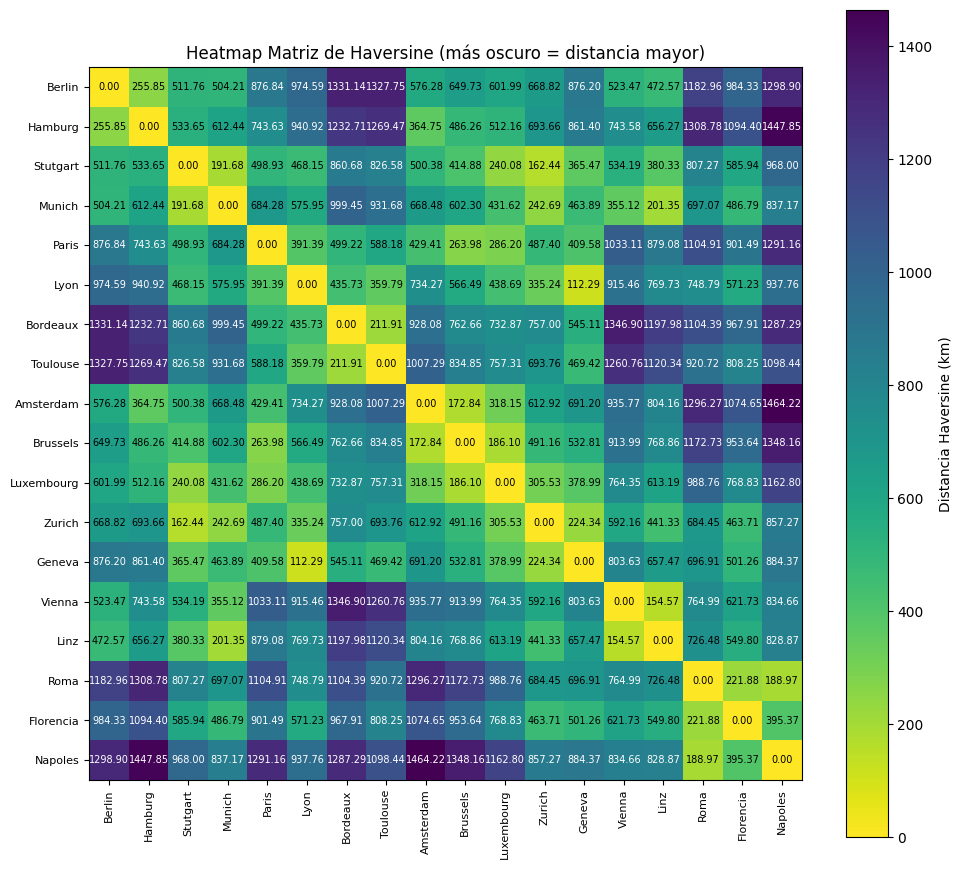

In [7]:
def plot_haversine_heatmap(D, labels=None):
    """
    D: matriz NxN de distancias (en metros)
    labels: lista/Serie de N etiquetas (opcional)
    """
    # Convertir a km
    M = (D / 1000).astype(float)

    fig, ax = plt.subplots(figsize=(10,9))
    
    im = ax.imshow(M, cmap='viridis_r', origin='upper')
    cbar = fig.colorbar(im, ax=ax, label='Distancia Haversine (km)')

    # Etiquetas
    if labels is None:
        labels = [str(i) for i in range(len(M))]
    ax.set_xticks(range(len(M))); ax.set_yticks(range(len(M)))
    ax.set_xticklabels(labels, rotation=90, fontsize=8)
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_title('Heatmap Matriz de Haversine (más oscuro = distancia mayor)')

    # Mostrar valores dentro de cada celda
    for i in range(len(M)):
        for j in range(len(M)):
            ax.text(j, i, f"{M[i, j]:.2f}", ha='center', va='center',
                    color='white' if M[i, j] > np.nanmax(M)/2 else 'black', fontsize=7)

    plt.tight_layout()
    plt.show()

labels = df['city'].tolist() if 'city' in df.columns else None
plot_haversine_heatmap(D, labels=labels)


# Lista Taboo

In [8]:
taboo = [
    (1, 7), (1, 8), (1, 17), (1, 18),
    (2, 6), (2, 7), (2, 8), (2, 17), (2, 18),
    (3, 9), (3, 10), (3, 16),
    (4, 7), (4, 8), (4, 11),
    (5, 15),
    (6, 2), (6, 9), (6, 14), (6, 15),
    (7, 1), (7, 2), (7, 4), (7, 14), (7, 18),
    (8, 1), (8, 2), (8, 4), (8, 14), (8, 15), (8, 16), (8, 18),
    (9, 3), (9, 6), (9, 15), (9, 18),
    (10, 3), (10, 17), (10, 18),
    (11, 4), (11, 16), (11, 17), (11, 18),
    (14, 6), (14, 7), (14, 8),
    (15, 5), (15, 6), (15, 8), (15, 9), (15, 16), (15, 18),
    (16, 3), (16, 8), (16, 11), (16, 15), 
    (17, 1), (17, 2), (17, 10), (17, 11),
    (18, 1), (18, 2), (18, 7), (18, 8), (18, 9), (18, 10), (18, 11), (18, 15)
]

# Crear Ruta

La ruta creada debe tomar en cuenta las restricciones 

In [9]:
def new_route_taboont():
    cities = list(range(1, 19))  # Ciudades del 1 al 18
    while True:
        route = random.sample(cities, len(cities))
        # Verificar por combinacion taboo
        forbidden = any(
            (route[i], route[i+1]) in taboo for i in range(len(route)-1)
        )
        # También podrías verificar el cierre del ciclo:
        #forbidden = forbidden or ((route[-1], route[0]) in taboo)
        
        if not forbidden:
            return route

In [10]:
print(new_route_taboont())

[12, 4, 2, 16, 9, 7, 3, 17, 6, 8, 13, 14, 15, 1, 10, 11, 5, 18]


# Evaluar Aptitud

In [11]:
def apt_ind(ind):
    sum_apt = 0.0
    for i in range(len(ind)-1):
        a = ind[i]   - 1
        b = ind[i+1] - 1
        sum_apt += D[a, b]
    return sum_apt

# Generar Poblacion Incial Valida con su Aptitud

In [12]:
def generar_poblacion(num):
    generacion = []
    for _ in range(num):
        ind = new_route_taboont()
        aptitud = round(apt_ind(ind), 2)
        generacion.append({"ind": ind, "apt": aptitud})
    return pd.DataFrame(generacion)


In [13]:
random.seed(5)
pob_5 = generar_poblacion(5)
pob_5

,ind,apt
0,"[15, 10, 5, 7, 16, 17, 8, 13, 2, 9, 4, 3, 1, 1...",9774205.03
1,"[6, 11, 10, 12, 4, 16, 7, 3, 17, 8, 5, 9, 14, ...",10656933.79
2,"[7, 11, 8, 6, 18, 12, 14, 13, 10, 9, 4, 16, 2,...",11600039.02
3,"[9, 8, 17, 18, 4, 6, 16, 5, 7, 15, 10, 1, 12, ...",11942940.69
4,"[15, 14, 5, 4, 13, 11, 9, 8, 6, 10, 1, 2, 12, ...",9696159.60


# Ordenar

In [14]:
def ordenar_poblacion(pob):
    pob = pob.sort_values(by='apt', ascending=True)
    pob = pob.reset_index(drop=True)
    return pob

In [15]:
ordenar_poblacion(pob_5)

,ind,apt
0,"[15, 14, 5, 4, 13, 11, 9, 8, 6, 10, 1, 2, 12, ...",9696159.60
1,"[15, 10, 5, 7, 16, 17, 8, 13, 2, 9, 4, 3, 1, 1...",9774205.03
2,"[6, 11, 10, 12, 4, 16, 7, 3, 17, 8, 5, 9, 14, ...",10656933.79
3,"[7, 11, 8, 6, 18, 12, 14, 13, 10, 9, 4, 16, 2,...",11600039.02
4,"[9, 8, 17, 18, 4, 6, 16, 5, 7, 15, 10, 1, 12, ...",11942940.69


# Recoleccion de Metricas

In [16]:
metrics_df = pd.DataFrame(columns=["ind","apt", "Avg_Gen_Fitness","Delta", "Avg_Delta"])
def metrics (poblacion, df_metricas, Grafrica = False, Clean = False):
    if Clean:
        df_metricas = df_metricas.iloc[0:0]
    nuevo_registro = poblacion.iloc[[0]].copy()
    nuevo_registro["Avg_Gen_Fitness"] = poblacion["apt"].mean()
    if df_metricas.shape[0] == 0:
        nuevo_registro["Delta"] = 0
        nuevo_registro["Avg_Delta"] = 0
    else:
        delta = df_metricas.iloc[-1]["apt"] - nuevo_registro.iloc[0]["apt"]
        nuevo_registro["Delta"] = delta
        avg_delta = df_metricas.iloc[-1]["Avg_Gen_Fitness"] - nuevo_registro.iloc[0]["Avg_Gen_Fitness"]
        nuevo_registro["Avg_Delta"] = avg_delta
    df_metricas = pd.concat([df_metricas, nuevo_registro], ignore_index=True)
    if Grafrica:
        plt.figure(figsize=(10,5))
        sns.lineplot(data=df_metricas, x=df_metricas.index, y="apt", label="Best Fitness")
        sns.lineplot(data=df_metricas, x=df_metricas.index, y="Avg_Gen_Fitness", label="Average Fitness")
        plt.xlabel("Generation")
        plt.ylabel("Fitness (Distance in meters)")
        plt.title("Fitness over Generations")
        plt.legend()
        plt.show()
    return df_metricas

# Selección

In [17]:
def parejas_rank(df):
    df_rs = df.reset_index(drop=True)
    parejas = []
    for i in range(0, len(df_rs)-1, 2):
        if i+1 < len(df_rs):
            pareja = (df_rs.iloc[i], df_rs.iloc[i+1])
            parejas.append(pareja)
    return parejas

def parejas_tournament(df):
    df_rs = df.reset_index(drop=True)
    parejas = []
    n = len(df_rs)
    for i in range(n // 2):
        pareja = (df_rs.iloc[i], df_rs.iloc[n - 1 - i])
        parejas.append(pareja)
    return parejas

# Cruza

## PMX

In [18]:
def _repair_no_dups(hijo, i, j, universo):
    """
    Repara un cromosoma para que sea una permutación sin repetidos,
    preservando el segmento [i:j] (no se toca).
    Reemplaza duplicados FUERA del segmento por genes faltantes.
    """
    n = len(hijo)
    # Posiciones fuera del segmento fijo
    fuera = list(range(0, i)) + list(range(j + 1, n))

    # Conteos y faltantes
    counts = Counter(hijo)
    present = set(hijo)
    missing = [g for g in universo if g not in present]  # orden según 'universo'
    miss_it = iter(missing)

    for pos in fuera:
        g = hijo[pos]
        if counts[g] > 1:
            counts[g] -= 1
            # Asignar el siguiente faltante
            nuevo = next(miss_it, None)
            if nuevo is None:
                continue
            hijo[pos] = nuevo
            counts[nuevo] = 1
    return hijo



In [19]:
def pmx(p1, p2, i=None, j=None):
    n = len(p1)
    assert len(p1) == len(p2) and n >= 2

    if i is None or j is None:
        i, j = sorted(random.sample(range(n), 2))

    h1 = [None] * n
    h2 = [None] * n

    # Copiar segmento central 
    h1[i:j+1] = p1[i:j+1]
    h2[i:j+1] = p2[i:j+1]

    # Mapeo bidireccional
    map12 = {}
    for a, b in zip(p1[i:j+1], p2[i:j+1]):
        map12[a] = b
        map12[b] = a

    seg1 = set(h1[i:j+1])  # genes fijos en h1 (de P1)
    seg2 = set(h2[i:j+1])  # genes fijos en h2 (de P2)

    # Rellenar h1 con P2 respetando el mapeo 
    for pos in list(range(0, i)) + list(range(j+1, n)):
        gene = p2[pos]
        count = 0
        original_gene = gene
        while gene in seg1:
            gene = map12[gene]
            count += 1
            if count > n:  # Previene ciclo infinito
                gene = original_gene
                break
        h1[pos] = gene

    # Rellenar h2 con P1 respetando el mapeo 
    for pos in list(range(0, i)) + list(range(j+1, n)):
        gene = p1[pos]
        count = 0
        original_gene = gene
        while gene in seg2:
            gene = map12[gene]
            count += 1
            if count > n:  # Previene ciclo infinito
                gene = original_gene
                break
        h2[pos] = gene

    universo = list(p1)
    h1 = _repair_no_dups(h1, i, j, universo)
    h2 = _repair_no_dups(h2, i, j, universo)

    return h1, h2

In [20]:
def cruzar_pmx_parejas(parejas):
    hijos = []
    for padre1, padre2 in parejas:
        h1, h2 = pmx(padre1['ind'], padre2['ind'])
        hijos.append(h1)
        hijos.append(h2)
    return hijos

## PBX

In [21]:
def pbx(p1, p2, positions=None, rng=None, n=18):
    if rng is None:
        rng = random

    if positions is None:
        k = rng.randint(1, max(1, n // 2))
        positions = sorted(rng.sample(range(n), k))

    child = [None] * n
    fixed = set()

    # Copiar posiciones desde p1
    for pos in positions:
        child[pos] = p1[pos]
        fixed.add(p1[pos])

    # Completar con p2 en orden relativo
    it = (gene for gene in p2 if gene not in fixed)
    for i in range(n):
        if child[i] is None:
            child[i] = next(it)

    return child

In [22]:
def cruzar_pbx_parejas(parejas):
    hijos = []
    for padre1, padre2 in parejas:
        h1 = pbx(padre1['ind'], padre2['ind'])
        h2 = pbx(padre2['ind'], padre1['ind'])
        hijos.append(h1)
        hijos.append(h2)
    return hijos

# Mutacion

## Scramble

In [23]:
def mut_scramble(ruta, fix_first=True, min_len=2, max_len=None):
    """
    Baraja aleatoriamente las ciudades dentro de un subsegmento [i:j].
    """
    if len(ruta) < 4:
        return ruta[:]  # nada útil que barajar

    # Soporte ruta cerrada (último = primero)
    closed = (ruta[0] == ruta[-1])
    path = ruta[:-1] if closed else ruta[:]

    n = len(path)
    start_idx = 1 if fix_first else 0
    usable = n - start_idx
    if usable < 3:
        return ruta[:]

    if max_len is None:
        max_len = usable  # sin límite superior

    max_len = max(min_len, min(max_len, usable))
    L = random.randint(min_len, max_len)
    i = random.randint(start_idx, n - L)
    j = i + L

    seg = path[i:j]
    random.shuffle(seg)
    new_path = path[:i] + seg + path[j:]

    return new_path + [new_path[0]] if closed else new_path


## Block Transpose

In [24]:
def mut_block_transpose(ruta, fix_first=True):
    """
    Intercambia dos bloques contiguos
    """
    if len(ruta) < 4:
        return ruta[:]

    closed = (ruta[0] == ruta[-1])
    path = ruta[:-1] if closed else ruta[:]

    n = len(path)
    start_idx = 1 if fix_first else 0
    if n - start_idx < 3:
        return ruta[:]

    # Elegir i, j, k con j-i>0 y k-j>0
    i = random.randint(start_idx, n - 3)
    j = random.randint(i + 1, n - 2)
    k = random.randint(j + 1, n)

    A = path[i:j]
    B = path[j:k]
    new_path = path[:i] + B + A + path[k:]

    return new_path + [new_path[0]] if closed else new_path


# Ciclo PMx

In [25]:
def dividir_mitad(df):
    n = len(df)
    mitad = n // 2 * 2  # redondea hacia abajo al par más cercano
    mitad1 = df.iloc[:mitad//2].reset_index(drop=True)
    mitad2 = df.iloc[mitad//2:mitad].reset_index(drop=True)
    return mitad1, mitad2


In [26]:
def Algoritmo_Genetico(poblacion_inicial, num_generaciones, Cruza='PMX', Grafrica=False):
    poblacion = poblacion_inicial.copy()

    df_metricas = pd.DataFrame(columns=["ind","apt", "Avg_Gen_Fitness","Delta", "Avg_Delta"])
    df_metricas = metrics(poblacion, df_metricas, Clean=True)

    patience = 10        # generaciones sin mejora para considerar "estancado"
    tol = 1e-9           # tolerancia de mejora
    stagnation = 0
    best_so_far = float(poblacion.iloc[0]["apt"])
    mutate_frac = 0.10   # 10% de la población

    mitad1, mitad2 = dividir_mitad(poblacion)

    for gen in range(num_generaciones):
        parejas_r = parejas_rank(mitad1)
        parejas_t = parejas_tournament(mitad2)

        if Cruza == 'PBX':
            hijos_r = cruzar_pbx_parejas(parejas_r)
            hijos_t = cruzar_pbx_parejas(parejas_t)
        elif Cruza == 'PMX':
            hijos_r = cruzar_pmx_parejas(parejas_r)
            hijos_t = cruzar_pmx_parejas(parejas_t)
        gen_hijos = pd.DataFrame({'ind': hijos_r + hijos_t})

        if stagnation >= patience:
            k = max(1, math.ceil(len(gen_hijos) * mutate_frac))
            idx_to_mutate = random.sample(range(len(gen_hijos)), k=min(k, len(gen_hijos)))
            # aplicar uno de las dos mutaciones (scramble o block transpose)
            for idx in idx_to_mutate:
                ind = gen_hijos.at[idx, 'ind']
                ind = mut_scramble(ind) if random.random() < 0.5 else mut_block_transpose(ind)
                gen_hijos.at[idx, 'ind'] = ind

        # evaluar hijos
        gen_hijos['apt'] = gen_hijos['ind'].apply(apt_ind)

        # integrar con población (como ya lo tenías)
        poblacion = pd.concat([poblacion, gen_hijos], ignore_index=True)
        poblacion = ordenar_poblacion(poblacion).iloc[:len(poblacion_inicial)].reset_index(drop=True)

        # actualizar métricas
        df_metricas = metrics(poblacion, df_metricas)

        curr_best = float(poblacion.iloc[0]['apt'])
        if (best_so_far - curr_best) > tol:  # mejora (menor distancia)
            best_so_far = curr_best
            stagnation = 0
        else:
            stagnation += 1

        # re-dividir para la próxima generación
        mitad1, mitad2 = dividir_mitad(poblacion)

    goat_ind = poblacion.iloc[0]['ind']
    goat_apt = (poblacion.iloc[0]['apt'])/1000
    print("Mejor ruta: ", goat_ind)
    print("Distancia en Km: ", round(goat_apt, 3))

    if Grafrica:
        plt.figure(figsize=(10,5))
        sns.lineplot(data=df_metricas, x=df_metricas.index, y="apt", label="Best Fitness")
        sns.lineplot(data=df_metricas, x=df_metricas.index, y="Avg_Gen_Fitness", label="Average Fitness")
        plt.xlabel("Generation")
        plt.ylabel("Fitness (Distance in meters)")
        plt.title("Fitness over Generations")
        plt.legend()
        plt.show()

    return poblacion, df_metricas, goat_ind


# Ejecucion

## PMX

C:\Users\death\AppData\Local\Temp\ipykernel_28464\1928038424.py:15: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



Mejor ruta:  [15, 14, 4, 17, 18, 16, 8, 7, 5, 6, 13, 12, 3, 11, 10, 9, 2, 1]
Distancia en Km:  5322.76


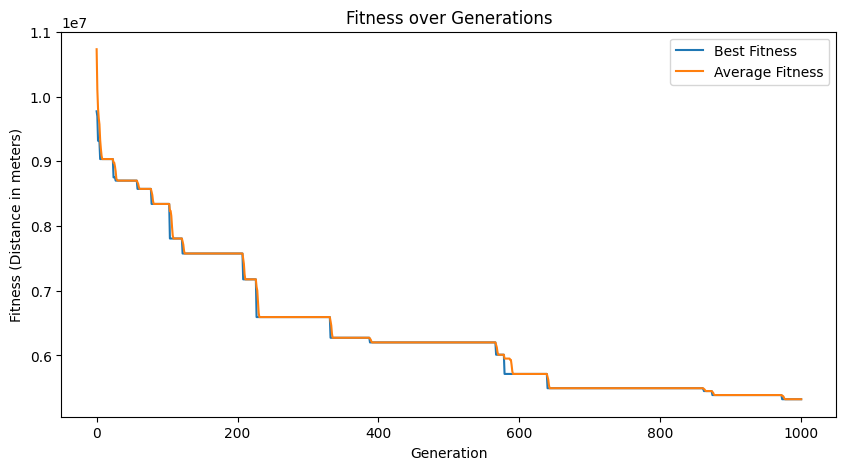

In [38]:
res = Algoritmo_Genetico(pob_5, 1000, 'PMX', Grafrica=True)
mapa_ruta_heatline(res[2])